# Bloque de Preprocesamiento – Proyecto Ecostress

> **Instituto Tecnológico de Costa Rica**  
>
> **Autores:** Alexandra Alfaro Elizondo, Francela Arias Vargas, Kendall Madrigal Campos  
>
> Este módulo implementa el filtrado de ruido y análisis estadístico previo a la codificación


In [27]:
import os  # módulo estándar de Python para manejar rutas y directorios
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)


# Visualización de la señal sin filtrado

Datos:
     Tiempo(s)         BPM
0            0   90.435881
1           10   91.375558
2           20   93.177147
3           30   92.253070
4           40   93.297168
..         ...         ...
122       1220  127.489200
123       1230  125.722564
124       1240  125.176371
125       1250  124.053356
126       1260  123.681245

[127 rows x 2 columns]


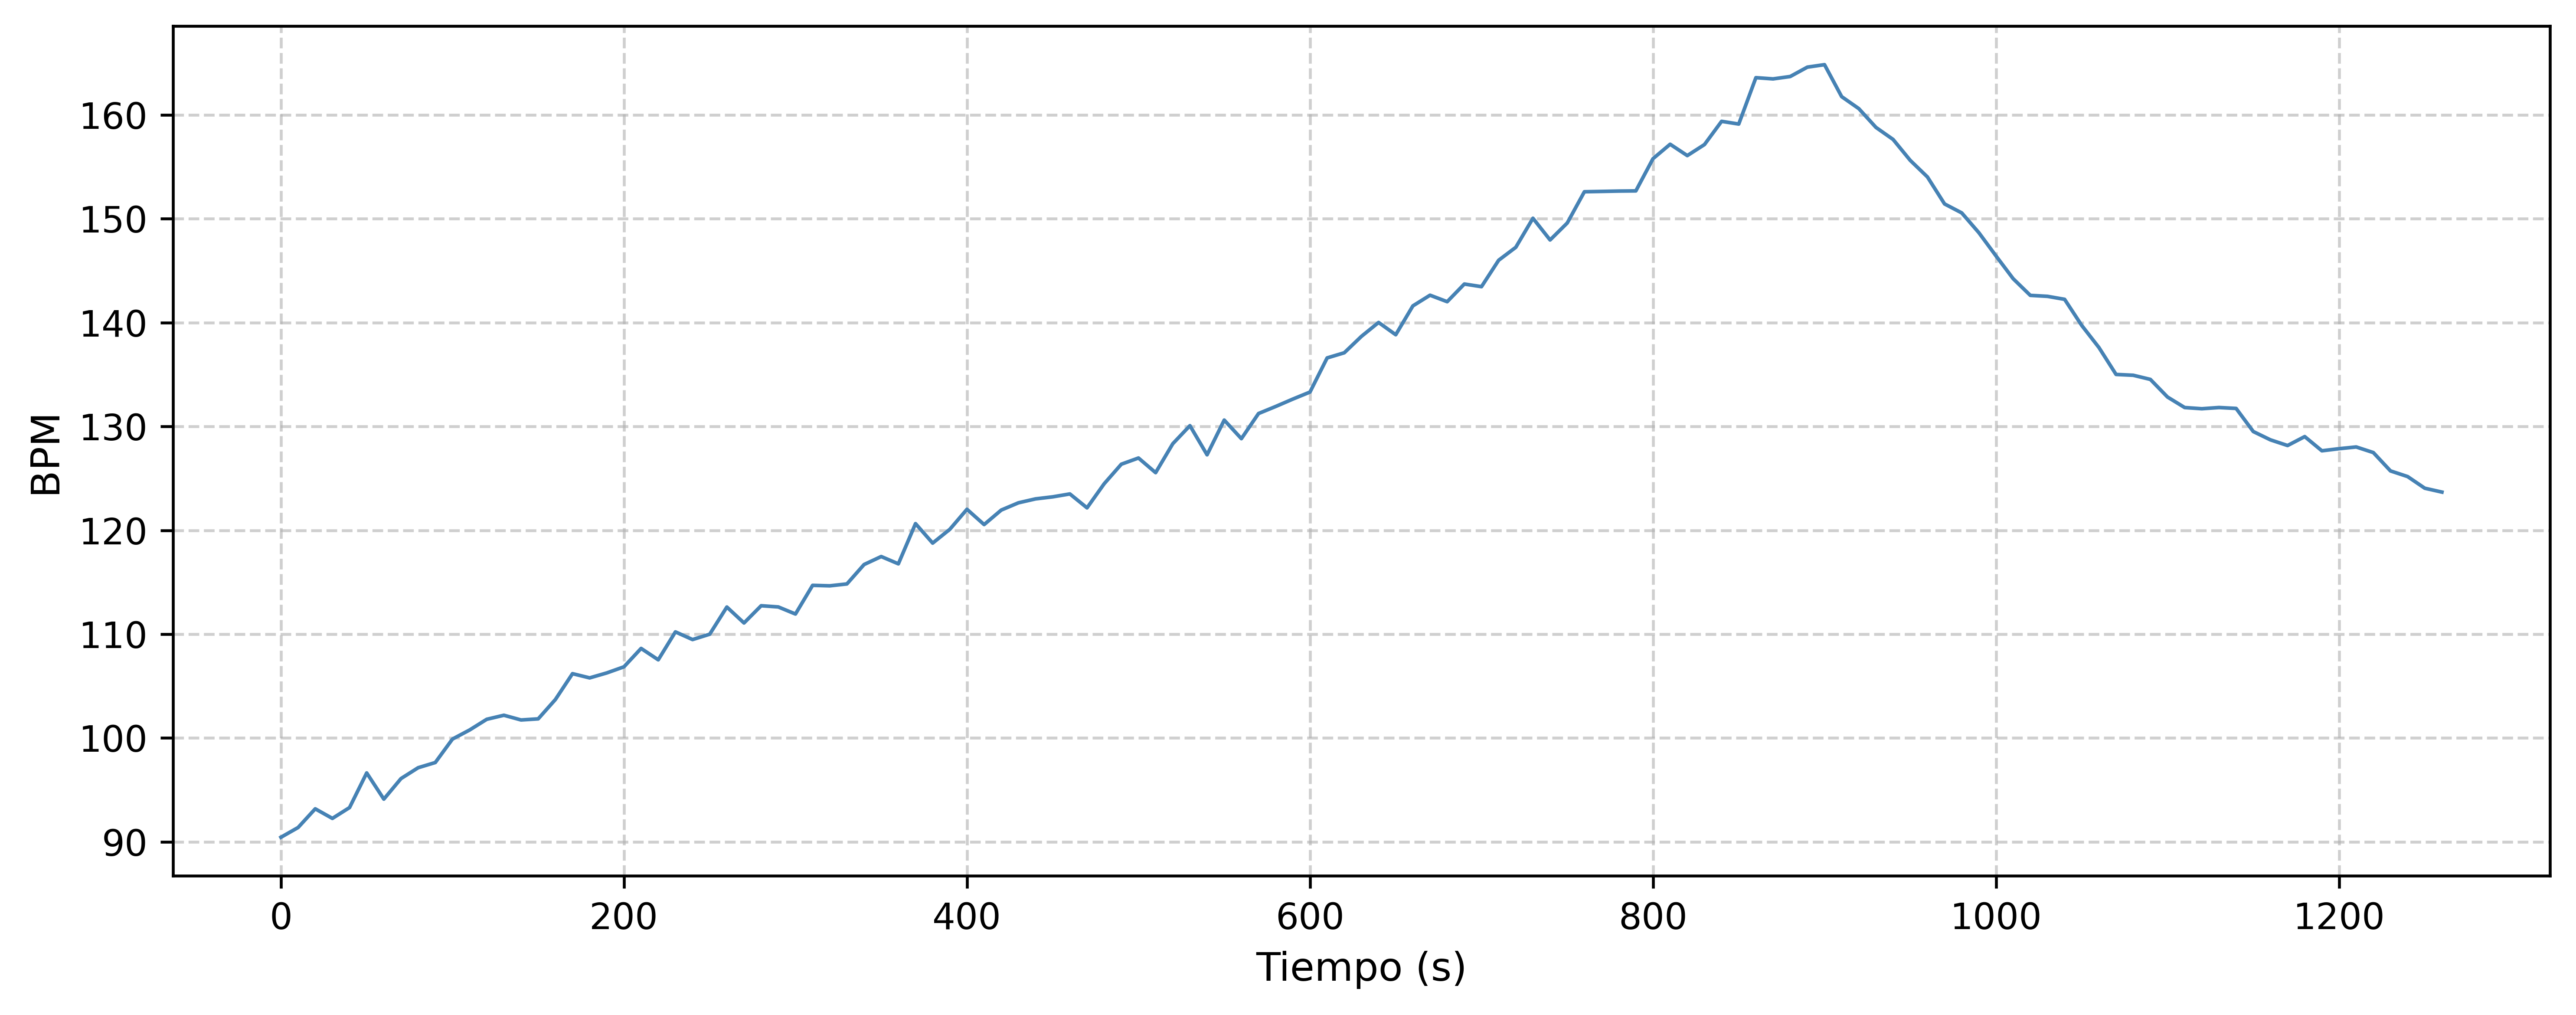

In [28]:
from scipy.stats import t
#  directorio de salida para mantener orden
OUT_DIR = Path("Documentacion/Avance 1/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# buscar archivos Excel en el mismo lugar del notebook
archivo_excel = 'Dataset.xlsx'
# cargar el archivo Excel en un DataFrame de pandas
data = pd.read_excel(archivo_excel)

# mostrar los datos completos
print("Datos:")
print(data)
t = data["Tiempo(s)"]
x = data["BPM"]
plt.figure(figsize=(10, 4), dpi=600)
plt.plot(t, x, color='steelblue', linewidth=1)
plt.xlabel("Tiempo (s)", fontsize=11)
plt.ylabel("BPM", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
output_path = OUT_DIR / "senal_original.png" # guardar figura en la ruta solicitada
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()

Info de filtros:
Media móvil: https://www.digikey.com/es/blog/introduction-to-signal-processing-moving-average-filter?msockid=37340f1d666a6d4b130b195167e66c39

Mediana: https://la.mathworks.com/help/images/ref/medfilt2.html

Savitzky–Golay: https://la.mathworks.com/help/signal/ref/sgolayfilt.html

Kalman: https://la.mathworks.com/discovery/kalman-filter.html, https://www.ucm.es/data/cont/media/www/pag-41459/Filtro%20de%20Kalman.pdf

Comparación de filtros: https://riunet.upv.es/server/api/core/bitstreams/f10b624a-bc6b-48f7-868d-dc2af0aa7f3d/content 
                                                                                                            

In [29]:
import pandas as pd

columnas = [
    "Filtro",
    "Eficacia de filtrado",
    "Preservación de información",
    "Tiempo de computación",
    "Complejidad de implementación",
    "Uso o aplicación recomendada"
]

# Datos completos de la tabla informativa
data = [
    [
        "Media móvil",
        "Media",
        "Media",
        "Bajo",
        "Muy baja",
        "Adecuado para suavizar ruido blanco en señales estables o con poca variabilidad. "
        "Ofrece una respuesta simple, aunque puede suavizar excesivamente los picos o transiciones rápidas."
    ],
    [
        "Mediana",
        "Alta",
        "Alta",
        "Bajo",
        "Baja",
        "Ideal para eliminar ruido impulsivo o picos aislados sin deformar la señal original. "
        "Muy utilizada en series temporales con valores atípicos."
    ],
    [
        "Savitzky–Golay",
        "Alta",
        "Muy alta",
        "Medio",
        "Media",
        "Suaviza la señal preservando su forma y tendencias principales. "
        "Es apropiado cuando se requiere mantener la morfología para análisis posteriores, "
        "como derivadas o picos característicos."
    ],

    [
        "Kalman",
        "Muy alta",
        "Alta",
        "Regular",
        "Alta",
        "Adecuado para señales dinámicas o con ruido correlacionado. "
        "Permite una estimación óptima cuando se dispone de un modelo del sistema "
        "o conocimiento previo de la dinámica de la señal."
    ],
]

# Crear DataFrame
tradeoff_info = pd.DataFrame(data, columns=columnas)

# Mostrar la tabla
print("Matriz trade-off informativa")
display(tradeoff_info)



Matriz trade-off informativa


,Filtro,Eficacia de filtrado,Preservación de información,Tiempo de computación,Complejidad de implementación,Uso o aplicación recomendada
0,Media móvil,Media,Media,Bajo,Muy baja,"Adecuado para suavizar ruido blanco en señales estables o con poca variabilidad. Ofrece una respuesta simple, aunque puede suavizar excesivamente los picos o transiciones rápidas."
1,Mediana,Alta,Alta,Bajo,Baja,Ideal para eliminar ruido impulsivo o picos aislados sin deformar la señal original. Muy utilizada en series temporales con valores atípicos.
2,Savitzky–Golay,Alta,Muy alta,Medio,Media,"Suaviza la señal preservando su forma y tendencias principales. Es apropiado cuando se requiere mantener la morfología para análisis posteriores, como derivadas o picos característicos."
3,Kalman,Muy alta,Alta,Regular,Alta,Adecuado para señales dinámicas o con ruido correlacionado. Permite una estimación óptima cuando se dispone de un modelo del sistema o conocimiento previo de la dinámica de la señal.


Se decide comparar los filtros: Mediana y Savitzky–Golay.

# Filtro mediana
Resultados de tiempo de ejecución:

In [34]:
import time # módulo estándar para medir tiempos de ejecución
from scipy.signal import medfilt  # función de filtro de mediana
kernel_size=5

# función que aplica el filtro y mide el tiempo de ejecución
def medir_tiempo_mediana(x, kernel_size=5):
    inicio = time.perf_counter()
    _ = medfilt(x, kernel_size=kernel_size)
    fin = time.perf_counter()
    return fin - inicio  # tiempo en segundos

# ejecutar 200 veces y almacenar los tiempos
n_ejecuciones = 200
tiempos = np.zeros(n_ejecuciones)

for i in range(n_ejecuciones):
    tiempos[i] = medir_tiempo_mediana(x, kernel_size)

# calcular estadísticas
tiempo_promedio = np.mean(tiempos)
tiempo_std = np.std(tiempos)

print(f" Resultados tiempo de ejecución (Filtro de Mediana):")
print(f"Número de ejecuciones: {n_ejecuciones}")
print(f"Tamaño de ventana: {window_size}")
print(f"Tiempo promedio: {tiempo_promedio*1000:.4f} ms")




 Resultados tiempo de ejecución (Filtro de Mediana):
Número de ejecuciones: 200
Tamaño de ventana: 5
Tiempo promedio: 0.0661 ms


In [36]:
import pandas as pd
df_tiempos = pd.DataFrame({"Ejecución": np.arange(1, n_ejecuciones+1), "Tiempo_s": tiempos})
df_tiempos.to_csv("tiempos_mediana.csv", index=False)

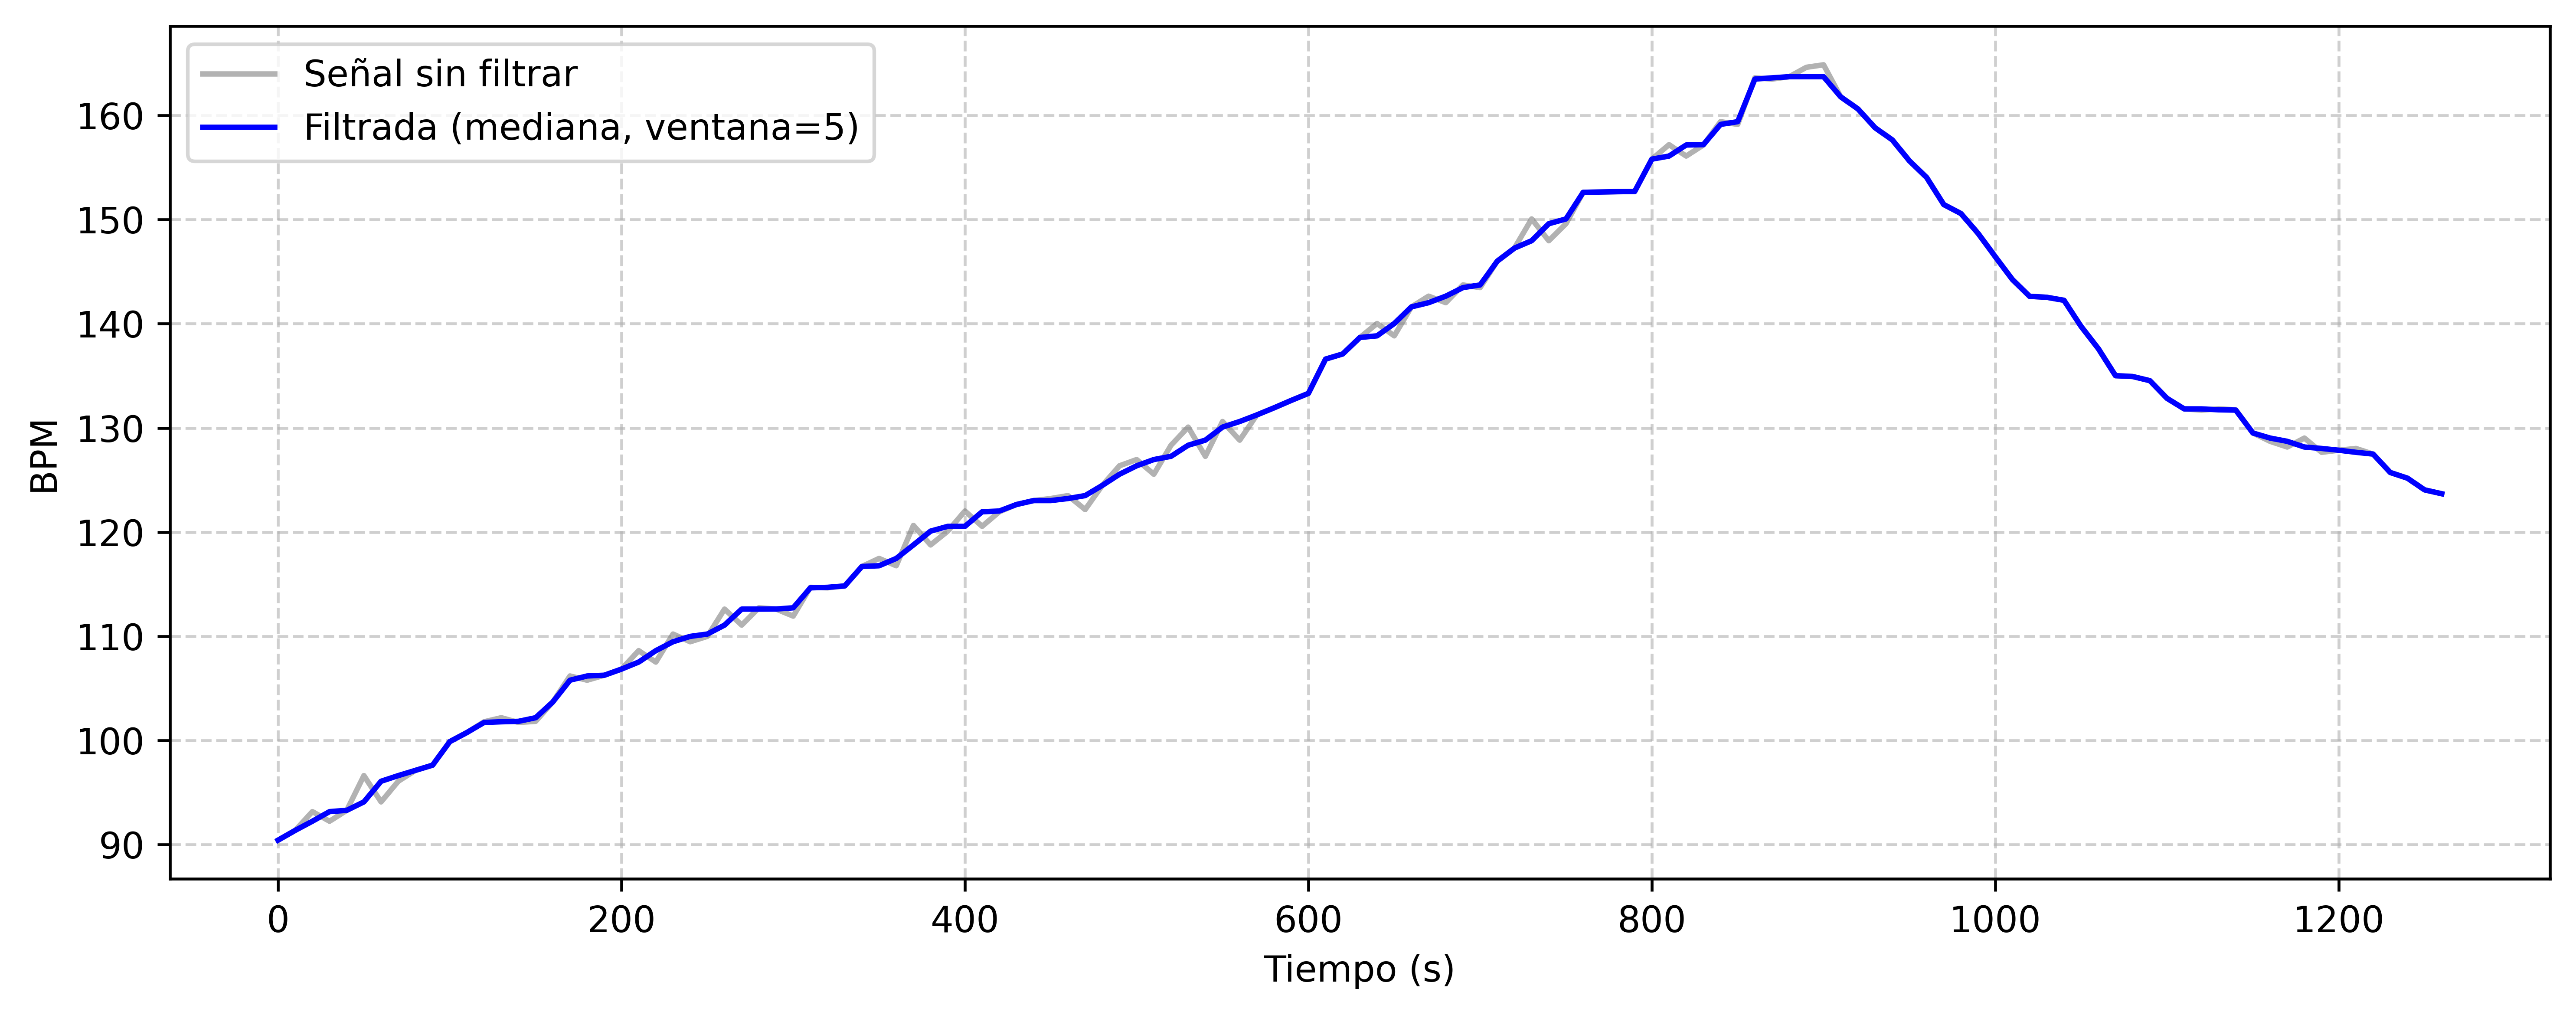

In [37]:
# Guardar los resultados individuales para análisis posterior
x_median = medfilt(x, kernel_size=window_size)

# Graficar comparación
plt.figure(figsize=(10,4),  dpi=600)
plt.plot(t, x, label='Señal sin filtrar', color='gray', alpha=0.6)
plt.plot(t, x_median, label=f'Filtrada (mediana, ventana={window_size})', color='blue')
plt.xlabel('Tiempo (s)')
plt.ylabel('BPM')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
output_path = OUT_DIR / "orig_vs_mediana.png" # guardar figura en la ruta solicitada
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()

# Filtro Savitzky–Golay
Resultados de tiempo de ejecución:

In [38]:
from scipy.signal import savgol_filter  # filtro Savitzky–Golay

# parámetros del filtro
window_length = 5 #debe ser impar y mayor que polyorder
polyorder = 2       # orden del polinomio de ajuste (controla y preserva la forma de la señal frente al ruido)

# función que aplica el filtro y mide el tiempo de ejecución 
def medir_tiempo_savgol(x, window_length=5, polyorder=2):
    inicio = time.perf_counter()
    _ = savgol_filter(x, window_length=window_length, polyorder=polyorder)
    fin = time.perf_counter()
    return fin - inicio  # tiempo en segundos

n_ejecuciones = 200
tiempos_savgol = np.zeros(n_ejecuciones)

for i in range(n_ejecuciones):
    tiempos_savgol[i] = medir_tiempo_savgol(x, window_length=window_length, polyorder=polyorder)

# calcular estadísticas
tiempo_promedio_savgol = np.mean(tiempos_savgol)
tiempo_std_savgol = np.std(tiempos_savgol)

# mostrar resultados
print(f" Resultados tiempo de ejecución (Filtro Savitzky–Golay):")
print(f"Número de ejecuciones: {n_ejecuciones}")
print(f"Tamaño de ventana: {window_length}")
print(f"Orden del polinomio: {polyorder}")
print(f"Tiempo promedio: {tiempo_promedio_savgol*1000:.4f} ms") 


# guardar resultados individuales
df_tiempos_savgol = pd.DataFrame({
    "Ejecución": np.arange(1, n_ejecuciones+1),
    "Tiempo_s": tiempos_savgol
})
df_tiempos_savgol.to_csv("tiempos_savgol.csv", index=False)

# aplicar el filtro una vez para graficar
x_savgol = savgol_filter(x, window_length=window_length, polyorder=polyorder)



 Resultados tiempo de ejecución (Filtro Savitzky–Golay):
Número de ejecuciones: 200
Tamaño de ventana: 5
Orden del polinomio: 2
Tiempo promedio: 0.6000 ms


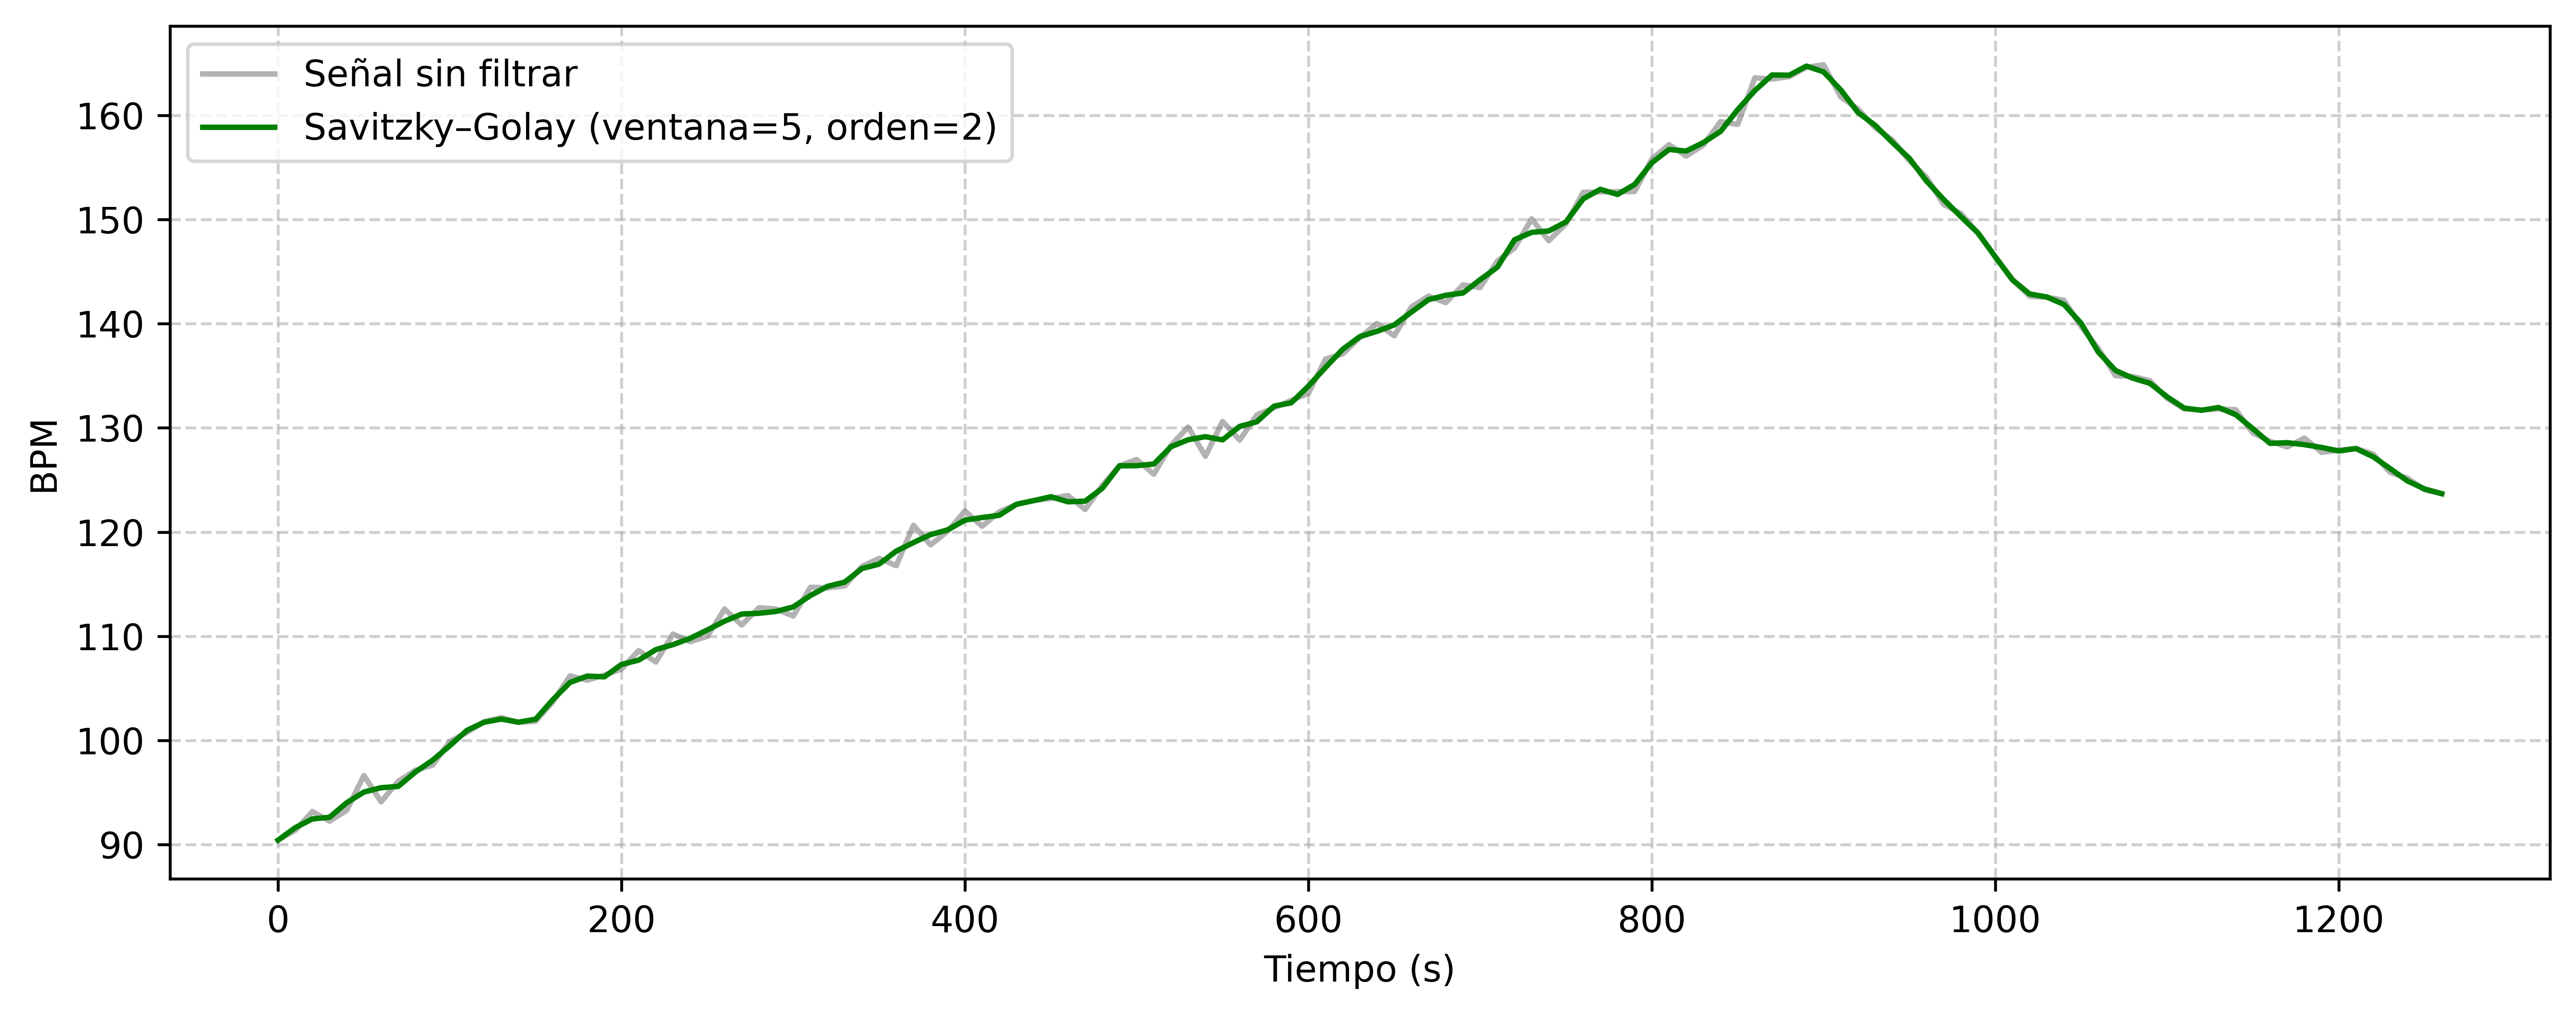

In [39]:
#Graficar 

plt.figure(figsize=(10,4), dpi=600)
plt.plot(t, x, label='Señal sin filtrar', color='gray', alpha=0.6)
plt.plot(t, x_savgol, label=f'Savitzky–Golay (ventana={window_length}, orden={polyorder})', color='green')
plt.xlabel('Tiempo (s)')
plt.ylabel('BPM')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
output_path = OUT_DIR / "orig_vs_savG.png" # guardar figura en la ruta solicitada
plt.savefig(output_path, dpi=600, bbox_inches='tight')
plt.show()

# Selección del filtro

Se evaluaron los filtros Mediana y Savitzky–Golay con el fin de determinar cuál ofrece un mejor equilibrio entre eficacia de filtrado, preservación de información y tiempo de ejecución, de acuerdo con los requerimientos del sistema ECOSTRESS.  
El filtro de Mediana fue seleccionado como método de preprocesamiento para el sistema ECOSTRESS, ya que presenta:

- Alta eficacia en la eliminación de ruido impulsivo.  
- Bajo costo computacional, aproximadamente seis veces menor que Savitzky–Golay.

$$
\frac{0.6ms}{0.0661ms} \approx 9.077ms
$$


- Simplicidad de implementación, ideal para portar al SoC nRF52832.  
- Estabilidad temporal comprobada en 200 ejecuciones.


In [40]:
OUT_DATA = Path("Documentacion/Avance 1/datos_filtrados") # carpeta destino
OUT_DATA.mkdir(parents=True, exist_ok=True)

salida = pd.DataFrame({
    "Tiempo_s": t,
    "Original": x,
    "Filtrado_Mediana": x_median
})

nombre = OUT_DATA / "filtro_mediana_w5.xlsx"

salida.to_excel(nombre, index=False, engine='openpyxl')